In [734]:
import librosa
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [735]:
path = r".\\lesson41_data"

# Augmetation and Feature Extraction

In [736]:
def add_noise(data, noise_factor=0.01):
    noise = np.random.randn(len(data))
    return data + noise_factor * noise

def time_shift(data, sampling_rate, shift_max=0.25):
    shift = np.random.randint(sampling_rate * shift_max)
    return np.roll(data, shift)

def pitch_shift(data, sampling_rate, n_steps=3.0):

    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=n_steps)

def extract_features(y, sr):
    # 1. MFCC 
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_std = np.std(mfcc.T, axis=0)
    
    # 2. Delta 
    mfcc_delta = librosa.feature.delta(mfcc, order=1)
    mfcc_delta_mean = np.mean(mfcc_delta.T, axis=0)
    
    # 3. Delta-2
   
    '''mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc_delta2_mean = np.mean(mfcc_delta2.T, axis=0)
    '''

    return np.hstack([mfcc_mean, mfcc_std, mfcc_delta_mean])#, mfcc_delta2_mean])

In [737]:
def create_static_dataset(data_dir):
    features = []
    labels = []
    classes = ['barbie', 'puppy']
    
    
    for label, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        files = [f for f in os.listdir(class_path) if f.endswith('.wav')]
        
        for file in files:
            file_path = os.path.join(class_path, file)
            y, sr = librosa.load(file_path, duration=4)
            
            features.append(extract_features(y, sr))
            labels.append(label)
            
            y_noise = add_noise(y)
            features.append(extract_features(y_noise, sr))
            labels.append(label)
            
            y_shift = time_shift(y, sr)
            features.append(extract_features(y_shift, sr))
            labels.append(label)

            y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=1.0) 
            features.append(extract_features(y_pitch, sr))
            labels.append(label)
            

    return np.array(features), np.array(labels)

In [738]:
X_static, y_static = create_static_dataset(path)


X_train, X_test, y_train, y_test = train_test_split(
    X_static, y_static, test_size=0.2, random_state=42, stratify=y_static
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create ModeL


In [739]:
model = Sequential([
    Dense(512, activation='elu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4), 

    Dense(256, activation='elu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='elu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-5)
early_stop = EarlyStopping(monitor='val_loss', patience=10,restore_best_weights=True)

c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Train Model

In [740]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[ reduce_lr, early_stop],
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6486 - loss: 2.9592 - val_accuracy: 0.8228 - val_loss: 2.5896 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8211 - loss: 2.5173 - val_accuracy: 0.8987 - val_loss: 2.3872 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8594 - loss: 2.3736 - val_accuracy: 0.8608 - val_loss: 2.2772 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8818 - loss: 2.2344 - val_accuracy: 0.8987 - val_loss: 2.1885 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9169 - loss: 2.0723 - val_accuracy: 0.8608 - val_loss: 2.0962 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9169 - loss: 2.0118 - val_accuracy: 0.9367 - val_loss: 1.9956 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9393 - loss: 1.8846 - val_acc

# Train\val lossses\acc

In [741]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training acc')
    plt.plot(epochs, val_acc, 'go-', label='Validation acc')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    plt.plot(epochs, val_loss, 'go-', label='Validation loss')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

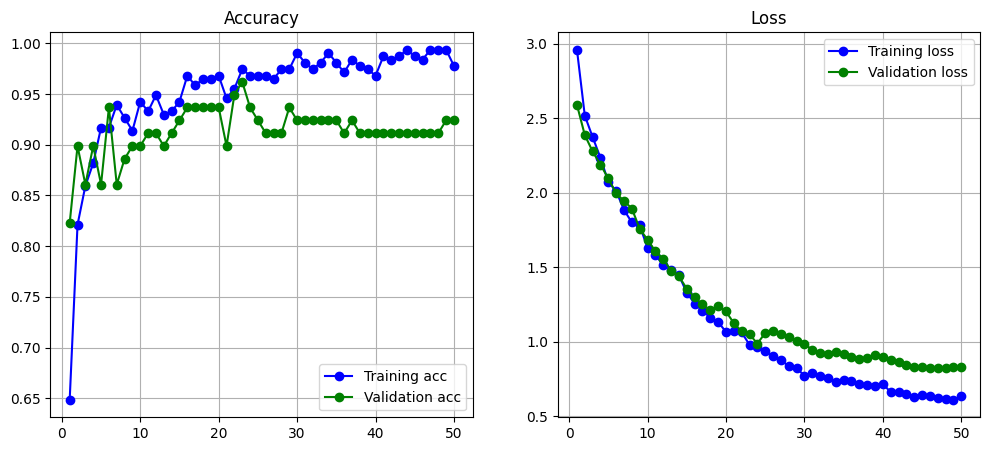

In [742]:
plot_history(history)

In [743]:
best_epoch_index = np.argmax(history.history['val_accuracy'])
best_epoch = best_epoch_index + 1 

print(f"Best epoch: {best_epoch}")

print(f"Train Loss:     {history.history['loss'][best_epoch_index]:.4f}")
print(f"Train Accuracy: {history.history['accuracy'][best_epoch_index]*100:.2f}%")

print(f"Val Loss:       {history.history['val_loss'][best_epoch_index]:.4f}")
print(f"Val Accuracy:   {history.history['val_accuracy'][best_epoch_index]*100:.2f}%")


Best epoch: 23
Train Loss:     0.9809
Train Accuracy: 97.44%
Val Loss:       1.0509
Val Accuracy:   96.20%


### Замечание
**Переобучение отсутсвует,т.к. *early_stop = EarlyStopping(monitor='val_loss', patience=10, **restore_best_weights=True)*** оставил веса с лучшей эпохи**


## On the fly pipeline

In [778]:
def dynamic_augmentation(y, sr):
    if np.random.rand() > 0.25:
        level = np.random.uniform(0.001, 0.015)
        y = add_noise(y, level)

    if np.random.rand() > 0.5:
        y = time_shift(y, sr, shift_max=0.3)

    if np.random.rand() < 0.5:
        steps = np.random.uniform(-2, 2)
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)
        
    return y

In [779]:
all_paths = []
all_labels = []
classes = ['barbie', 'puppy']

for label, class_name in enumerate(classes):
    class_path = os.path.join(path, class_name)
    files = [f for f in os.listdir(class_path) if f.endswith('.wav')]
    for file in files:
        all_paths.append(os.path.join(class_path, file))
        all_labels.append(label)

In [780]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)


In [781]:
train_features_for_scaler = []

for p in train_paths:
    y, sr = librosa.load(p, duration=4)
    train_features_for_scaler.append(extract_features(y, sr))

scaler = StandardScaler()
scaler.fit(train_features_for_scaler)


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [782]:
del train_features_for_scaler

In [783]:
def train_mapper(file_path, label):
    def _process(fp, lbl):
        fp_str = fp.numpy().decode('utf-8')
        y, sr = librosa.load(fp_str, duration=4)
        
        y = dynamic_augmentation(y, sr)
        
        feat = extract_features(y, sr)
        feat = scaler.transform(feat.reshape(1, -1)).flatten()
        return feat.astype(np.float32), np.array(lbl, dtype=np.int32)

    feat, lbl = tf.py_function(_process, [file_path, label], [tf.float32, tf.int32])
    feat.set_shape((120,))
    lbl.set_shape([])
    return feat, lbl

def val_mapper(file_path, label):
    def _process(fp, lbl):
        fp_str = fp.numpy().decode('utf-8')
        y, sr = librosa.load(fp_str, duration=4)
        
        feat = extract_features(y, sr)
        
        feat = scaler.transform(feat.reshape(1, -1)).flatten()
        return feat.astype(np.float32), np.array(lbl, dtype=np.int32)

    feat, lbl = tf.py_function(_process, [file_path, label], [tf.float32, tf.int32])
    feat.set_shape((120,))
    lbl.set_shape([])
    return feat, lbl

In [784]:
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths))
            .map(train_mapper, num_parallel_calls=tf.data.AUTOTUNE) 
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(val_mapper, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

In [785]:
model_dynamic = Sequential([
    Dense(512, activation='elu', kernel_regularizer=l2(0.001), input_shape=(120,)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='elu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='elu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)

model_dynamic.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [786]:
history_dynamic = model_dynamic.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60, 
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 753ms/step - accuracy: 0.5000 - loss: 3.3507 - val_accuracy: 0.6000 - val_loss: 2.8780
Epoch 2/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 750ms/step - accuracy: 0.5769 - loss: 3.0186 - val_accuracy: 0.8000 - val_loss: 2.7427
Epoch 3/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 764ms/step - accuracy: 0.6154 - loss: 2.9969 - val_accuracy: 0.7500 - val_loss: 2.7000
Epoch 4/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 606ms/step - accuracy: 0.6538 - loss: 2.8062 - val_accuracy: 0.7500 - val_loss: 2.6633
Epoch 5/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 675ms/step - accuracy: 0.6282 - loss: 2.7981 - val_accuracy: 0.8000 - val_loss: 2.6216
Epoch 6/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 700ms/step - accuracy: 0.7179 - loss: 2.7414 - val_accuracy: 0.7500 - val_loss: 2.5889
Epoch 7/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 732ms/step - accuracy: 0.7051 - loss: 2.5964 - val_accuracy: 0.7500 - val_loss: 2.5833
Epoch 8/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 617ms/step - accuracy: 0.6667 - loss: 2.7670 - val_accuracy: 0.7000 - val_loss:

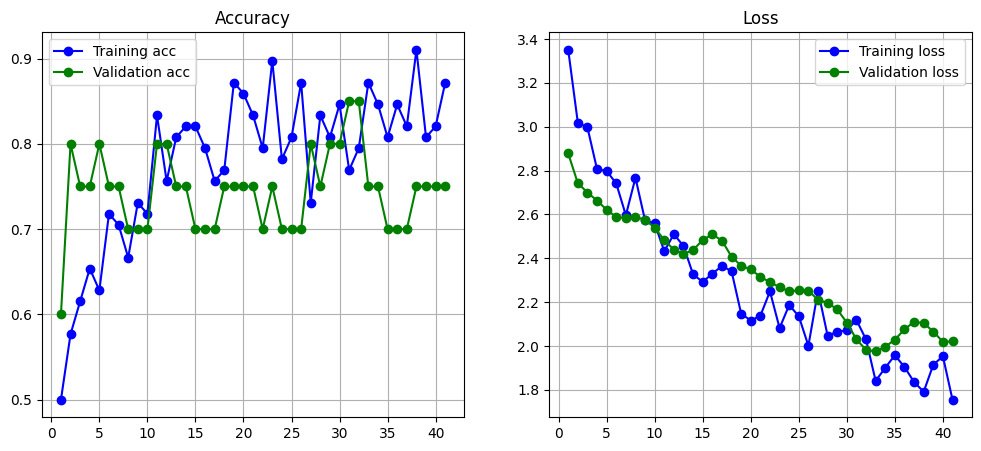

In [787]:
plot_history(history_dynamic)

In [788]:
final_loss, final_acc = model_dynamic.evaluate(val_ds, verbose=0)

val_loss_history = history_dynamic.history['val_loss']
best_epoch_index = np.argmin(val_loss_history)
best_epoch = best_epoch_index + 1 

best_val_loss = val_loss_history[best_epoch_index]
best_val_acc = history_dynamic.history['val_accuracy'][best_epoch_index]
best_train_loss = history_dynamic.history['loss'][best_epoch_index]
best_train_acc = history_dynamic.history['accuracy'][best_epoch_index]

print(f"Best epoch: {best_epoch}")

print(f"Train Loss:        {best_train_loss:.4f}")
print(f"Train Accuracy:    {best_train_acc*100:.2f}%")

print(f"Best Val Loss:     {best_val_loss:.4f}")
print(f"Best Val Accuracy: {best_val_acc*100:.2f}%")


Best epoch: 33
Train Loss:        1.8410
Train Accuracy:    87.18%
Best Val Loss:     1.9752
Best Val Accuracy: 75.00%


In [ ]:
[]